<a href="https://colab.research.google.com/github/alvarogonmar/Computational-Biology-Analysis/blob/main/ml2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving SistemaCalidadAgua_Caji_wide3(Sheet 1).csv to SistemaCalidadAgua_Caji_wide3(Sheet 1) (3).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 45 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Date                                 132 non-null    object 
 1   Total alkalinity                     132 non-null    float64
 2   Aluminum                             132 non-null    float64
 3   Arsenic                              132 non-null    float64
 4   Barium                               132 non-null    float64
 5   Cadmium                              132 non-null    float64
 6   Total chlorides                      132 non-null    float64
 7   Copper                               132 non-null    float64
 8   Fecal coliforms                      132 non-null    int64  
 9   Total coliforms                      132 non-null    int64  
 10

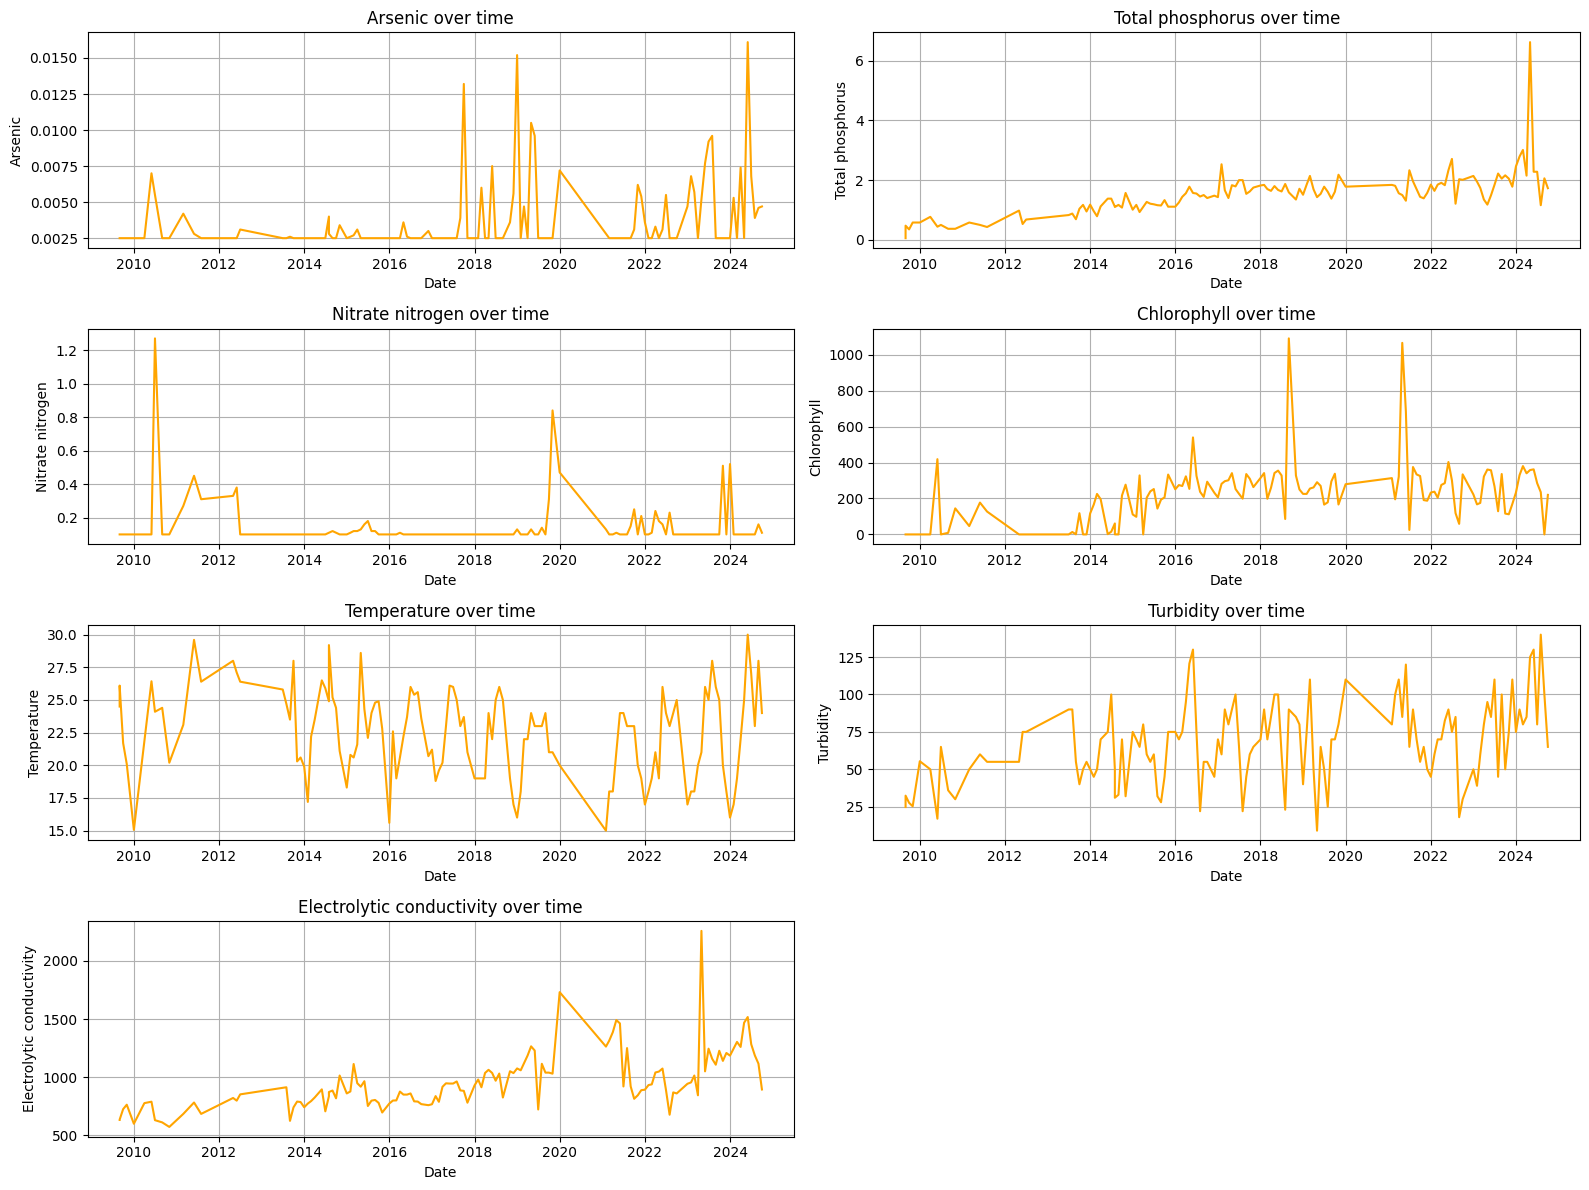

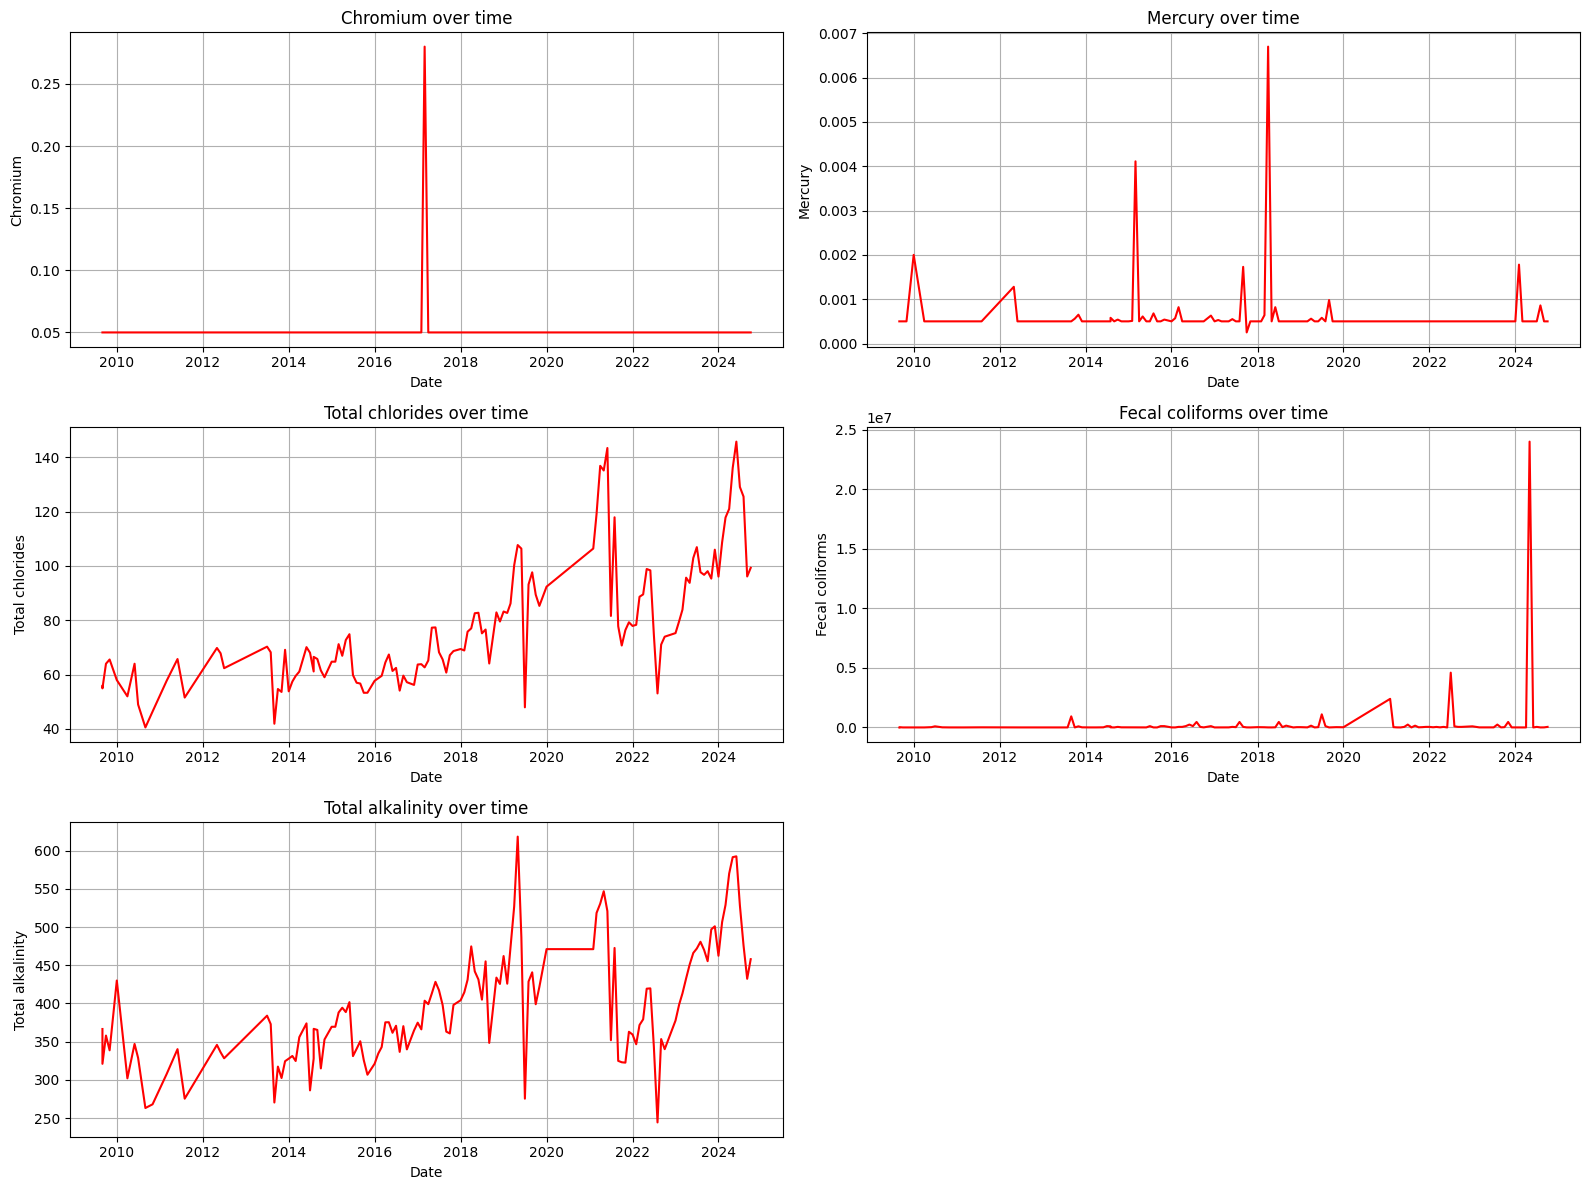

{'Experiment 1 - Train (2009-2023)': (122, 46),
 'Experiment 1 - Test (2024)': (10, 46),
 'Experiment 2 - Train (2009-2024)': (132, 46)}

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt


from google.colab import files
uploaded = files.upload()


df = pd.read_csv("/content/SistemaCalidadAgua_Caji_wide3(Sheet 1).csv")

print(df.info())
print(df.describe())

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year





###### DATA EXPLORATION ######

selected_columns = [
    'Date', 'Arsenic', 'Total phosphorus', 'Nitrate nitrogen', 'Chlorophyll',
    'Temperature', 'Turbidity', 'Electrolytic conductivity'
]
df_selected = df[selected_columns].sort_values('Date')


plt.figure(figsize=(16, 12))
for i, col in enumerate(selected_columns[1:], 1):
    plt.subplot(4, 2, i)
    plt.plot(df_selected['Date'], df_selected[col], color='orange')
    plt.title(f"{col} over time")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.grid(True)

plt.tight_layout()
plt.show()




###### WORST POLLUTANTS ######

worst_pollutants = [
    'Chromium', 'Mercury', 'Total chlorides', 'Fecal coliforms', 'Total alkalinity'
]

df_worst_pollutants = df[['Date'] + worst_pollutants].sort_values('Date')

plt.figure(figsize=(16, 12))
for i, col in enumerate(worst_pollutants, 1):
    plt.subplot(3, 2, i)
    plt.plot(df_worst_pollutants['Date'], df_worst_pollutants[col], color='red')
    plt.title(f"{col} over time")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.grid(True)

plt.tight_layout()
plt.show()



##### EXPERIMENTS #####

#### training ML #####

train_df = df[df['Year'] <= 2023]
test_2024_df = df[df['Year'] == 2024]

train_exp2_df = df[df['Year'] <= 2024]

# Show summary of split data
summary = {
    'Experiment 1 - Train (2009-2023)': train_df.shape,
    'Experiment 1 - Test (2024)': test_2024_df.shape,
    'Experiment 2 - Train (2009-2024)': train_exp2_df.shape,
}

summary



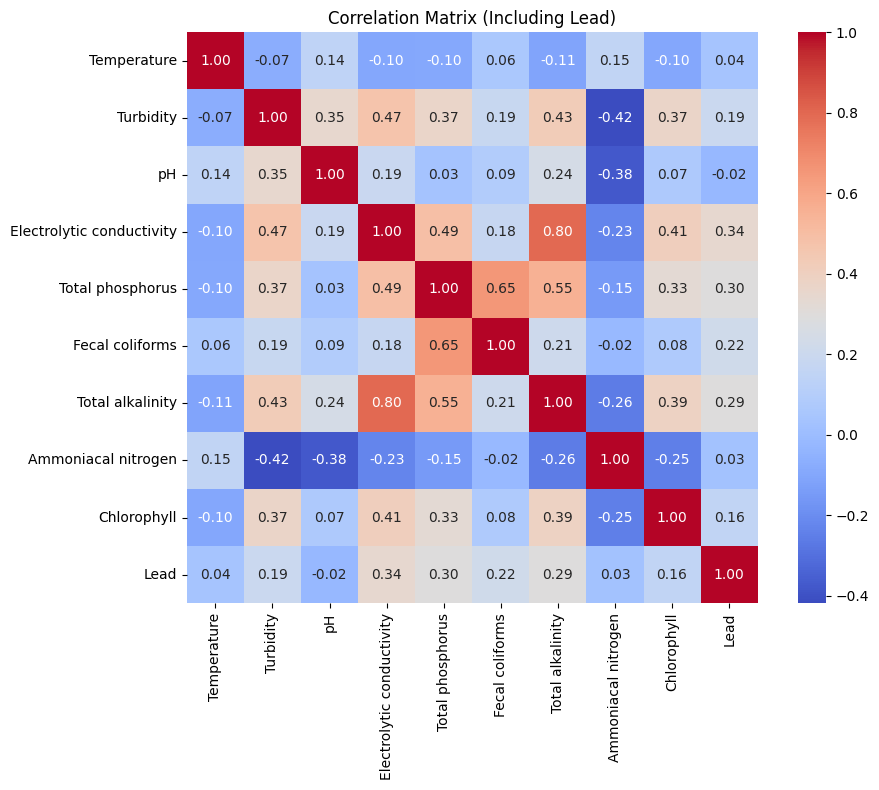

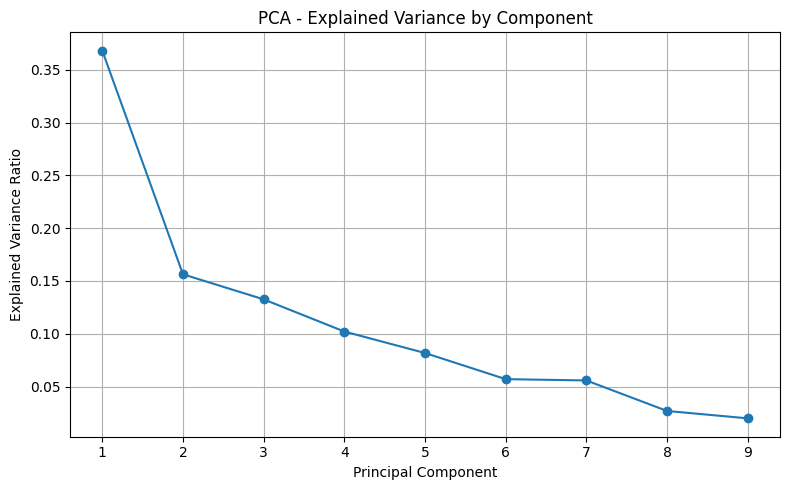

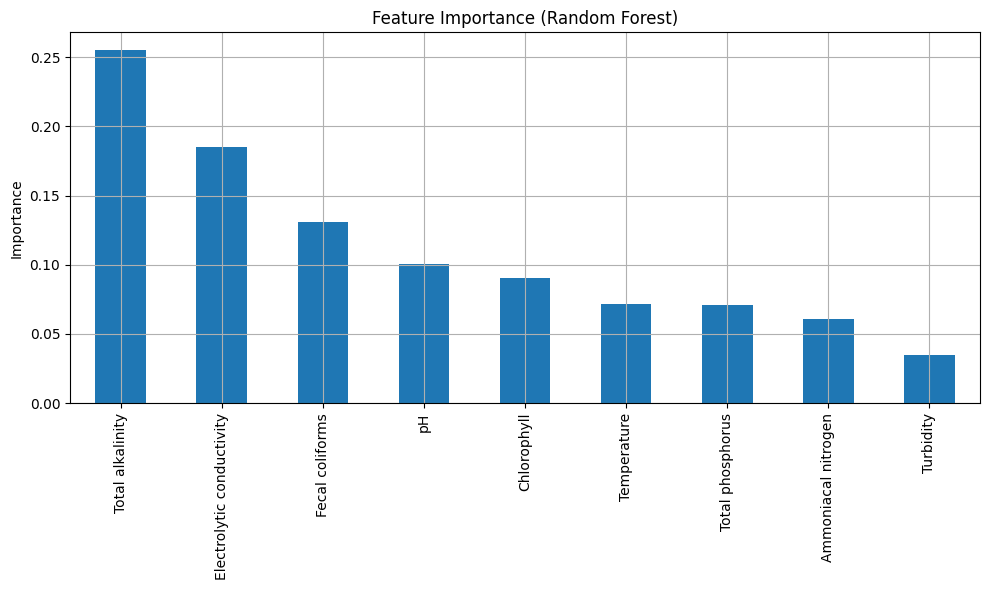

In [ ]:
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Correlation Matrix
corr_matrix = df[features + ['Lead']].corr()

# 2. PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

pca = PCA(n_components=len(features))
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_

# 3. Feature Importances from the trained Random Forest model
feature_importances = pd.Series(model_exp2.feature_importances_, index=features).sort_values(ascending=False)

# Plot 1: Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix (Including Lead)")
plt.tight_layout()
plt.show()

# Plot 2: PCA Explained Variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(features)+1), explained_variance, marker='o')
plt.title("PCA - Explained Variance by Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3: Feature Importances
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='bar')
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.grid(True)
plt.tight_layout()
plt.show()


1️⃣ 🔗 Correlation Matrix

    Lead has moderate correlation with:

        Total alkalinity

        Electrolytic conductivity

        Weak/negative correlation with Chlorophyll and Temperature

    This helps identify features with strong influence or potential redundancy.

2️⃣ 📊 PCA (Principal Component Analysis)

    The first 2–3 components explain a large portion of the variance.

    This suggests we could reduce dimensionality while keeping most of the signal.

    PCA components are linear combos — great for models like SVM or LSTM with fewer features.

3️⃣ 🧱 Random Forest Feature Importance

Top predictive features for Lead:

    Total alkalinity

    Electrolytic conductivity

    Ammoniacal nitrogen

    pH

    Temperature

These features align with known chemistry — they're key in influencing heavy metal behavior.

Mean Absolute Error: 0.0034350000000000014
R² Score: -0.20184988780622848


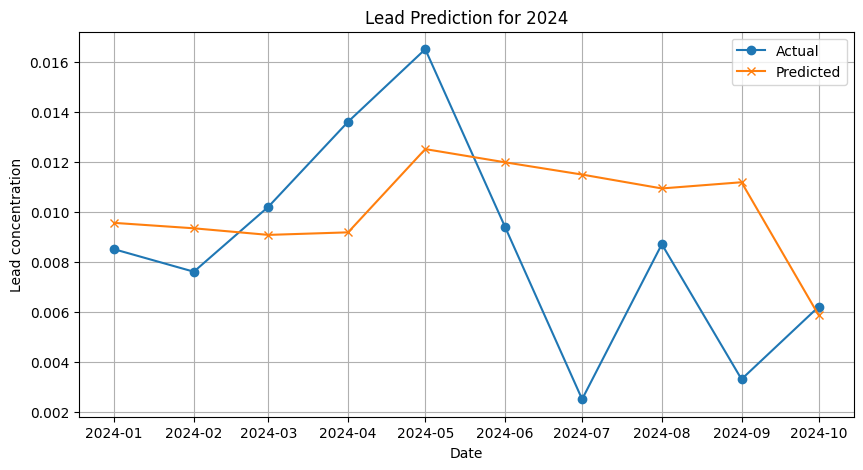

In [ ]:
###### 2024 PREDICTION ###### RF

# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Step 2: Load and preprocess data
df = pd.read_csv("SistemaCalidadAgua_Caji_wide3(Sheet 1).csv")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year

# Step 3: Select features and target
features = ['Temperature', 'Turbidity', 'pH', 'Electrolytic conductivity',
            'Total phosphorus', 'Fecal coliforms', 'Total alkalinity',
            'Ammoniacal nitrogen', 'Chlorophyll']

target = 'Lead'

# Step 4: Split into train and test sets
train_df = df[df['Year'] <= 2023]
test_df = df[df['Year'] == 2024]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# Step 5: Train Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 6: Predict and evaluate
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

# Step 7: Plot predictions
plt.figure(figsize=(10, 5))
plt.plot(test_df['Date'], y_test.values, label="Actual", marker='o')
plt.plot(test_df['Date'], y_pred, label="Predicted", marker='x')
plt.title("Lead Prediction for 2024")
plt.xlabel("Date")
plt.ylabel("Lead concentration")
plt.legend()
plt.grid(True)
plt.show()






Saving SistemaCalidadAgua_Caji_wide3(Sheet 1).csv to SistemaCalidadAgua_Caji_wide3(Sheet 1) (4).csv


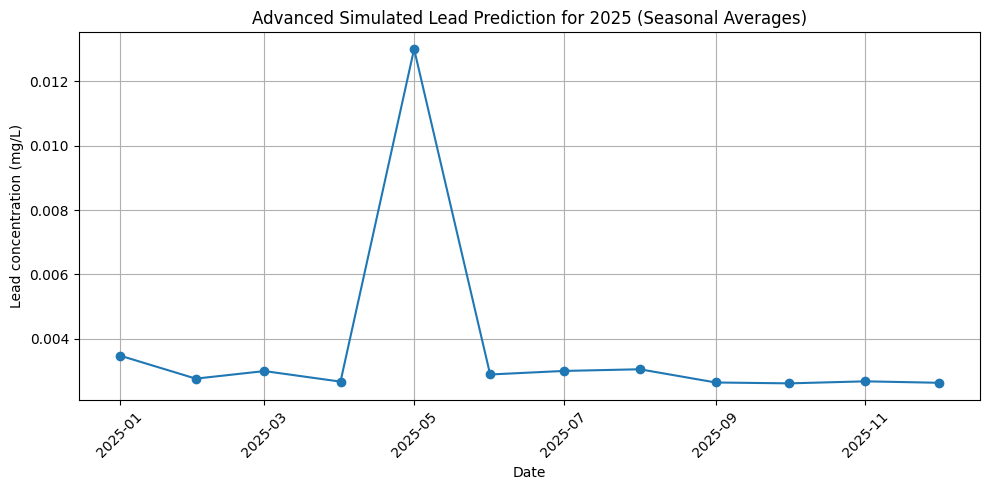

In [ ]:
###### 2025 PREDICTIONS ###### RF

# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# Step 2: Upload and read the dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("SistemaCalidadAgua_Caji_wide3(Sheet 1).csv")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Step 3: Define features and target variable
features = ['Temperature', 'Turbidity', 'pH', 'Electrolytic conductivity',
            'Total phosphorus', 'Fecal coliforms', 'Total alkalinity',
            'Ammoniacal nitrogen', 'Chlorophyll']
target = 'Lead'

# Step 4: Train model on all data (2009–2024)
X_train = df[features]
y_train = df[target]

model_exp2 = RandomForestRegressor(n_estimators=100, random_state=42)
model_exp2.fit(X_train, y_train)

# Step 5: Generate seasonal monthly averages for 2025
monthly_averages = df.groupby('Month')[features].mean().reset_index()
X_2025_advanced = monthly_averages[features]

# Step 6: Predict Lead for each month in 2025
y_2025_advanced_pred = model_exp2.predict(X_2025_advanced)

# Step 7: Simulate monthly dates for 2025
date_range_2025 = pd.date_range(start='2025-01-01', periods=12, freq='MS')

# Step 8: Plot the predictions
plt.figure(figsize=(10, 5))
plt.plot(date_range_2025, y_2025_advanced_pred, marker='o', linestyle='-')
plt.title("Advanced Simulated Lead Prediction for 2025 (Seasonal Averages)")
plt.xlabel("Date")
plt.ylabel("Lead concentration (mg/L)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##### DON'T SWIM IN MAY -AIDA #######

Saving SistemaCalidadAgua_Caji_wide3(Sheet 1).csv to SistemaCalidadAgua_Caji_wide3(Sheet 1) (6).csv
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0412
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0302
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0274
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0219
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0311
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0246
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0187
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0235
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0307
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0181
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0259
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0303
Epoch 13/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0266
Epoch 14/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0249
Epoch 15/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0161
Epoch 16/100
30/

<ipython-input-14-eb518c1fb68a>:95: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


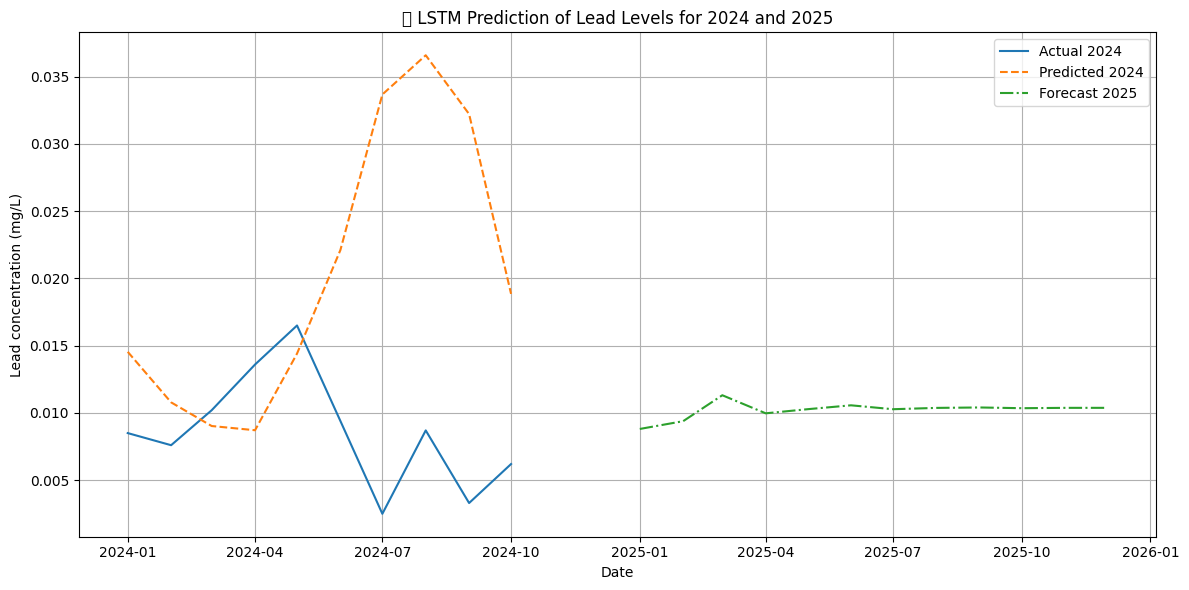

In [ ]:
###### 2024 and 2025 PREDICTION TESTING ###### LSTM
##### we enjoyed working together so much that we decided to do LSTM as well ########
#### una cerveza por favor #####

# Step 0: Install TensorFlow
!pip install tensorflow

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Step 2: Upload and Load Data
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("SistemaCalidadAgua_Caji_wide3(Sheet 1).csv")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df = df.sort_values('Date').reset_index(drop=True)

# Step 3: Select top features from earlier analysis
features = ['Total alkalinity', 'Electrolytic conductivity', 'Ammoniacal nitrogen', 'pH', 'Temperature']
target = 'Lead'

# Step 4: Normalize data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[[target]])

# Step 5: Create LSTM sequences
def create_sequences(X, y, time_steps=3):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 3
X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)

# Step 6: Split for 2024 prediction
split_index = df[df['Year'] <= 2023].shape[0] - time_steps
X_train_lstm = X_seq[:split_index]
y_train_lstm = y_seq[:split_index]
X_test_2024 = X_seq[split_index:]
y_test_2024 = y_seq[split_index:]

# Step 7: Build LSTM Model
model = Sequential([
    LSTM(64, activation='relu', input_shape=(time_steps, len(features))),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train_lstm, y_train_lstm, epochs=100, batch_size=4, verbose=1)

# Step 8: Predict 2024
y_pred_2024_scaled = model.predict(X_test_2024)
y_pred_2024 = scaler_y.inverse_transform(y_pred_2024_scaled)
y_test_2024_true = scaler_y.inverse_transform(y_test_2024)

# Step 9: Forecast 2025 using rolling input (recursive prediction)
X_last_seq = X_scaled[-time_steps:]
X_2025_forecast = []

current_seq = X_last_seq.copy()
for _ in range(12):
    pred_scaled = model.predict(current_seq[np.newaxis, :, :])
    pred_inv = scaler_y.inverse_transform(pred_scaled)
    X_2025_forecast.append(pred_inv[0][0])

    # Create next sequence (replace last row with average input to simulate continuation)
    next_input = np.mean(current_seq, axis=0)
    current_seq = np.vstack([current_seq[1:], next_input])

# Step 10: Plot everything
# Fix date range to match prediction length
date_2024 = df[df['Year'] == 2024]['Date'].iloc[:len(y_pred_2024)]
date_2025 = pd.date_range(start='2025-01-01', periods=12, freq='MS')  # Use 'MS' (Month Start)

# Plot predictions and forecast
plt.figure(figsize=(12, 6))
plt.plot(date_2024, y_test_2024_true.flatten(), label="Actual 2024")
plt.plot(date_2024, y_pred_2024.flatten(), label="Predicted 2024", linestyle='--')
plt.plot(date_2025, X_2025_forecast, label="Forecast 2025", linestyle='-.')
plt.title("🧠 LSTM Prediction of Lead Levels for 2024 and 2025")
plt.xlabel("Date")
plt.ylabel("Lead concentration (mg/L)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


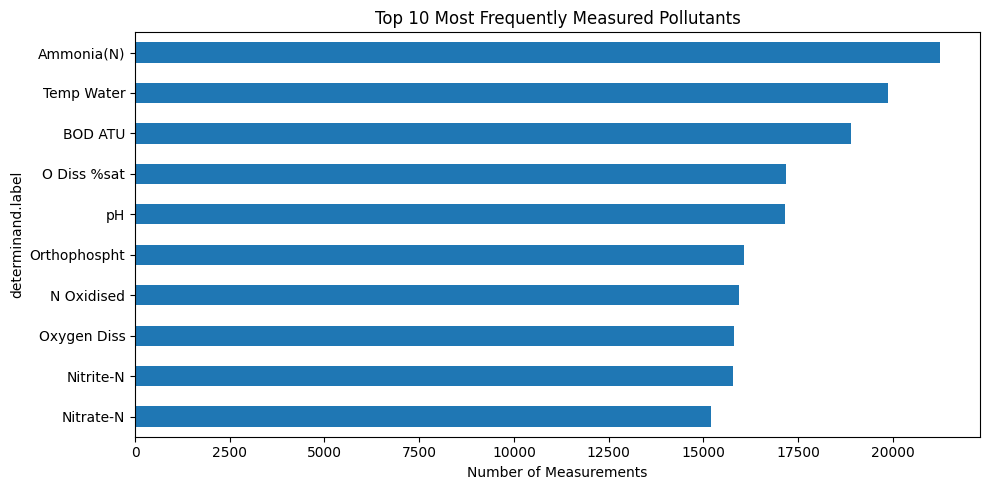

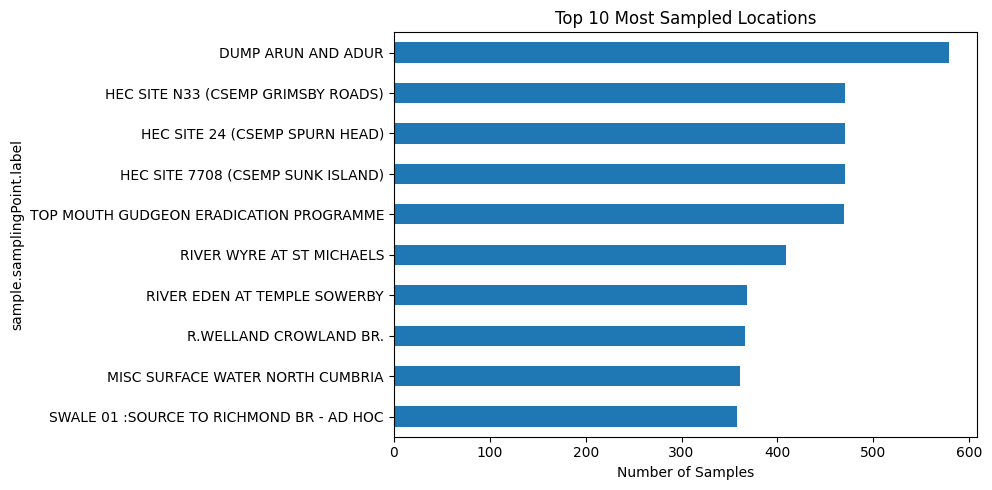

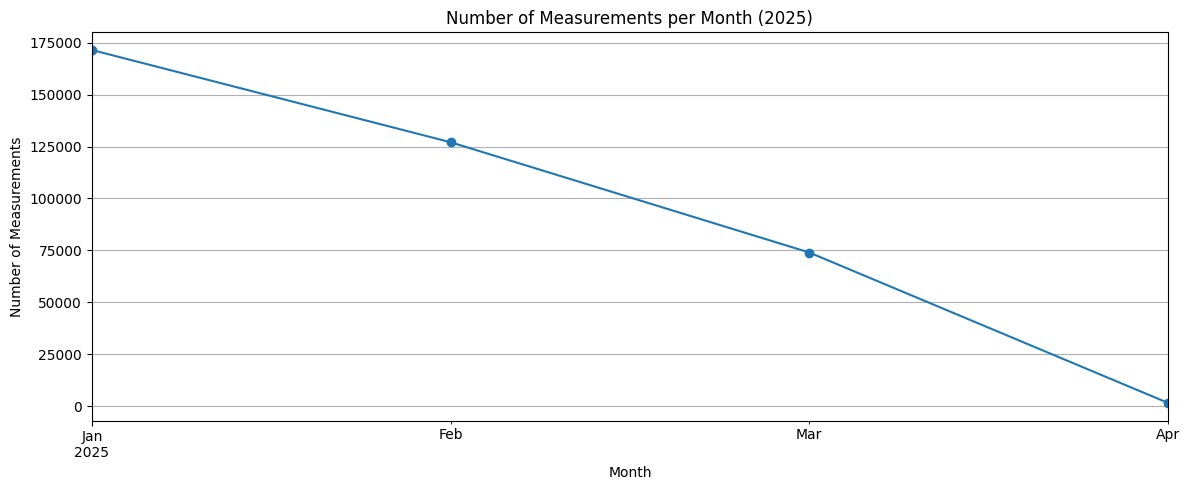

In [ ]:
# Re-load the UK dataset in case the environment reset
uk_df = pd.read_csv("/content/2025.csv")

# Convert sample date to datetime
uk_df['sample.sampleDateTime'] = pd.to_datetime(uk_df['sample.sampleDateTime'], errors='coerce')

# 1. Top 10 most frequently measured pollutants
top_dets = uk_df['determinand.label'].value_counts().head(10)

# 2. Top 10 most sampled locations
top_locations = uk_df['sample.samplingPoint.label'].value_counts().head(10)

# 3. Number of measurements per month
uk_df['Month'] = uk_df['sample.sampleDateTime'].dt.to_period('M')
monthly_counts = uk_df['Month'].value_counts().sort_index()

# Plot 1: Most frequent pollutants
plt.figure(figsize=(10, 5))
top_dets.plot(kind='barh')
plt.title("Top 10 Most Frequently Measured Pollutants")
plt.xlabel("Number of Measurements")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Plot 2: Most sampled locations
plt.figure(figsize=(10, 5))
top_locations.plot(kind='barh')
plt.title("Top 10 Most Sampled Locations")
plt.xlabel("Number of Samples")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Plot 3: Sampling frequency over time
plt.figure(figsize=(12, 5))
monthly_counts.plot(marker='o')
plt.title("Number of Measurements per Month (2025)")
plt.xlabel("Month")
plt.ylabel("Number of Measurements")
plt.grid(True)
plt.tight_layout()
plt.show()
